In [96]:
import kagglehub
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
import os

In [11]:
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)
plt.rcParams['figure.figsize'] = (6, 6)
sns.set_style('whitegrid')

In [2]:
load_dotenv() # Fetch API key

True

In [3]:
# Download latest version
output_dir = 'dataset'
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud", output_dir=output_dir)

print("Path to dataset files:", path)

100%|██████████| 66.0M/66.0M [00:05<00:00, 12.6MB/s]

Extracting files...


Path to dataset files: dataset


In [ ]:
df = pd.read_csv(os.path.join(output_dir, 'creditcard.csv'), usecols=['Amount'])
df.describe()

<Axes: >

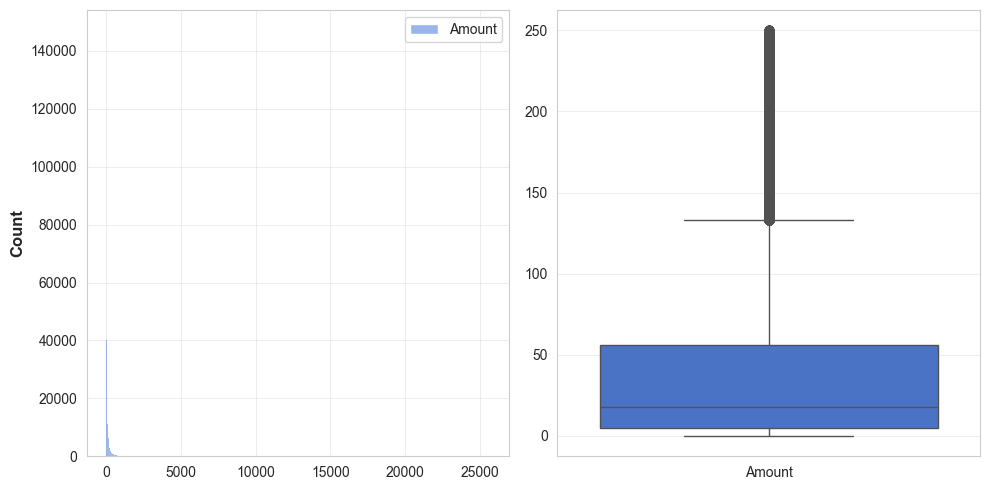

In [104]:
plt.figure(figsize=[10, 5])
plt.subplot(121); sns.histplot(df)
plt.subplot(122); sns.boxplot(data=df[df['Amount'] < 250])

### Removing outliers

<Axes: >

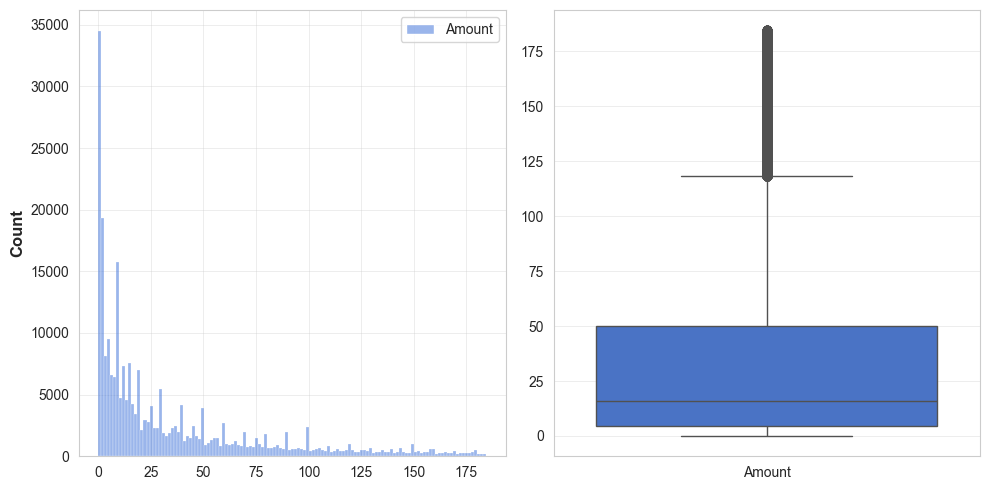

In [108]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

remove_outliers_df = df[(df > lower_bound) & (df < upper_bound)]

plt.figure(figsize=[10, 5])
plt.subplot(121); sns.histplot(remove_outliers_df)
plt.subplot(122); sns.boxplot(remove_outliers_df)

### Imputation by tendency

<Axes: >

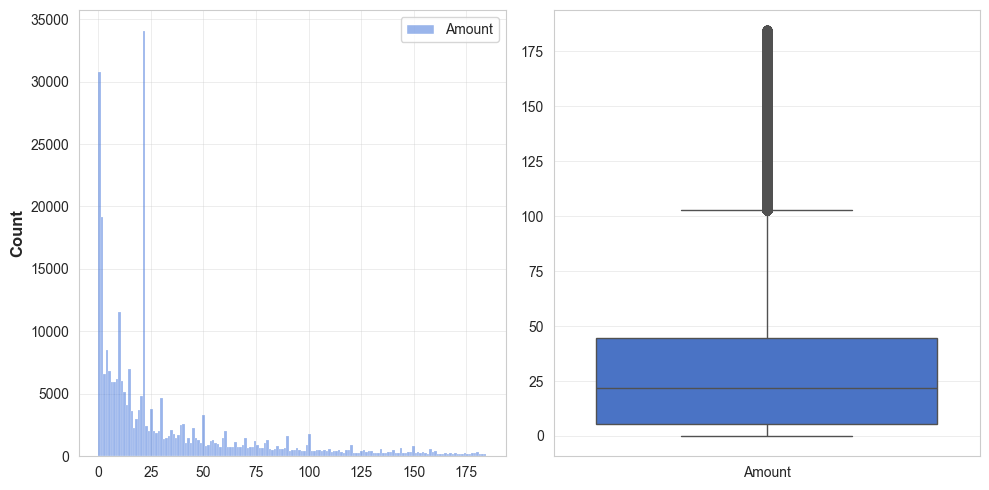

In [76]:
median_imputed = df.copy()

median = median_imputed[target].median()

mask = (
    (median_imputed < lower_bound) |
    (median_imputed > upper_bound)
)
median_imputated[mask] = median

plt.figure(figsize=[10, 5])
plt.subplot(121); sns.histplot(median_imputated)
plt.subplot(122); sns.boxplot(data=median_imputated)

# Transformation

<Axes: >

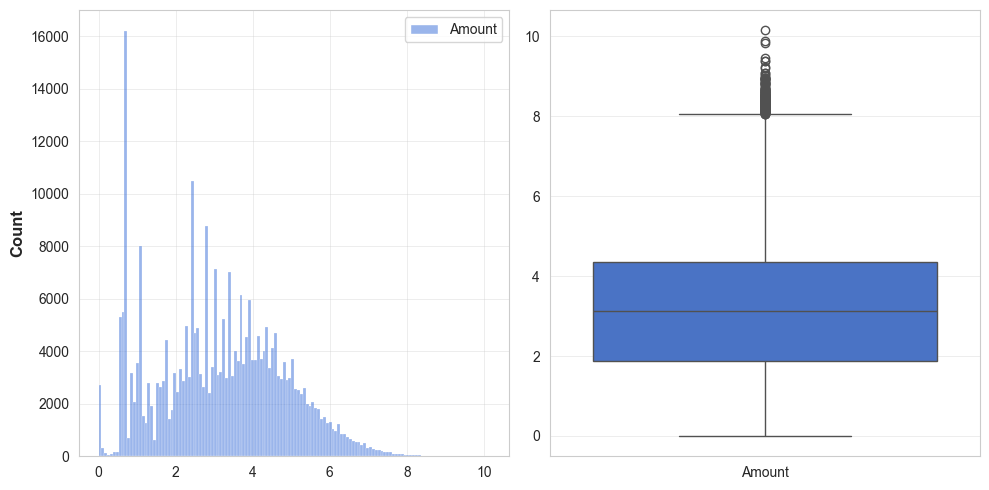

In [75]:
log_df = df.copy()
log_df = np.log1p(df)
plt.figure(figsize=[10, 5])
plt.subplot(121); sns.histplot(log_df)
plt.subplot(122); sns.boxplot(data=log_df)

# Winsorization

<Axes: >

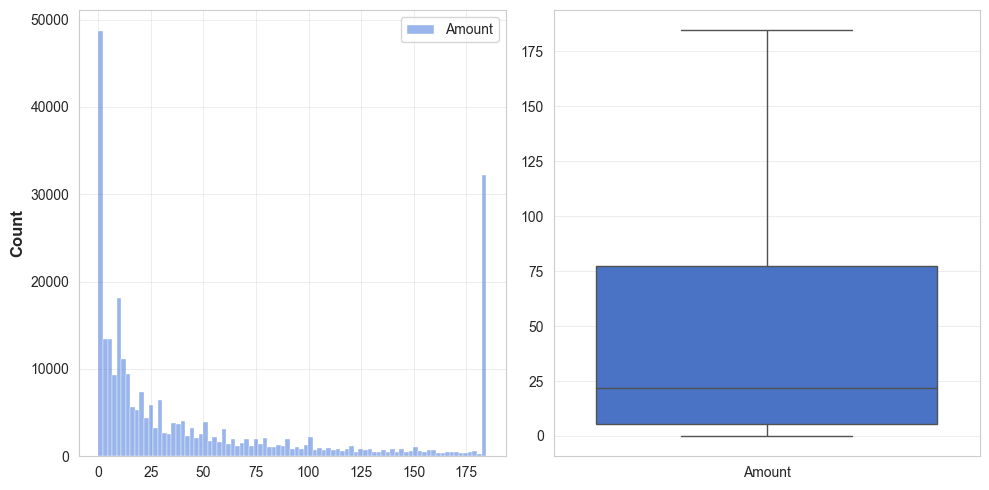

In [95]:
winsorized_df = df.copy()
winsorized_df = winsorized_df.clip(lower=lower_bound, upper=upper_bound, axis=1)

plt.figure(figsize=[10, 5])
plt.subplot(121); sns.histplot(data=winsorized_df)
plt.subplot(122); sns.boxplot(data=winsorized_df)

# Algorithmic Imputation

<Axes: >

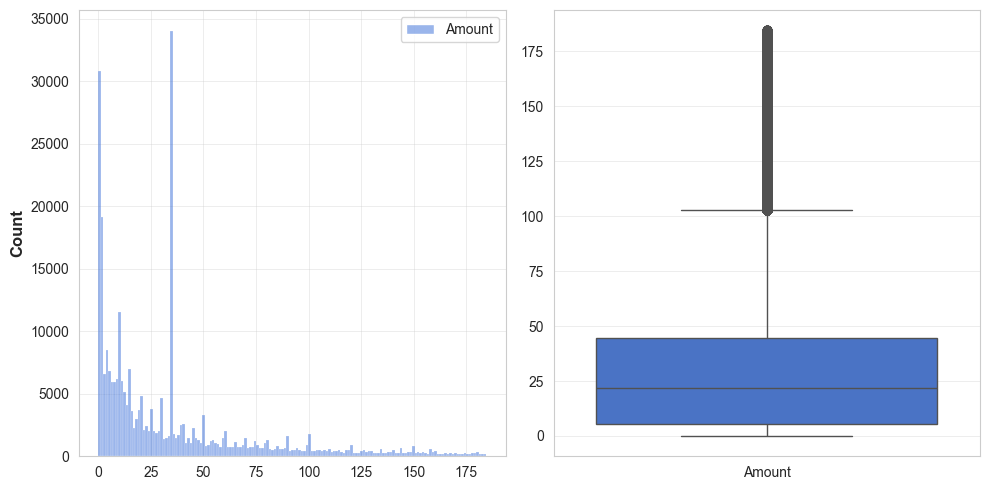

In [107]:
# Replace outliers with Null
augmented_df = df.copy()

augmented_df[mask] = np.nan
columns = df.columns

# Apply scaling
scaler = RobustScaler()
scaled_data = scaler.fit_transform(augmented_df)
scaled_df = pd.DataFrame(scaled_data, columns=columns)

# Impute missing values
knn_imputer = KNNImputer(n_neighbors=5) # adjust count of neighbors
imputed_data = knn_imputer.fit_transform(scaled_data)

# Inverse the transformation
original_scale_data = scaler.inverse_transform(imputed_data)
original_scale_df = pd.DataFrame(original_scale_data, columns=scaled_df.columns)

plt.figure(figsize=[10, 5])
plt.subplot(121); sns.histplot(data=original_scale_df)
plt.subplot(122); sns.boxplot(data=original_scale_df)